# Import all libraries

In [9]:
print("I am great:)")

I am great:)


In [10]:
import numpy as np
from scipy.integrate import solve_ivp

In [11]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [12]:
import torch
from torch import nn

# Write derivatives and gradients

In [13]:
class simple_NN2(nn.Module):
    def __init__(self):
        super(simple_NN2, self).__init__()
        self.linear_tanh_stack = nn.Sequential(
            nn.Linear(2,16), #--input 2 variables--
            nn.Tanh(),
            nn.Linear(16,32),
            nn.Tanh(),
            nn.Linear(32,16),
            nn.Tanh(),
            nn.Linear(16,1),
        )
    def forward(self, x, t):
        x_stack = torch.cat([x,t], dim=1)
        out = self.linear_tanh_stack(x_stack)
        return out    

In [14]:
def df(output: torch.Tensor, input_var: torch.Tensor, order: int=1)->torch.Tensor:
    """Compute neural network derivative with respect to input features using PyTorch autograd engine"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
                df_value,
                input_var,
                grad_outputs=torch.ones_like(input_var),
                create_graph=True,
                retain_graph=True
        )[0]
    return df_value

def dfdt(model: simple_NN2, x: torch.Tensor, t:torch.Tensor, order: int=1):
    f_value = model(x,t)
    return df(f_value, t, order=order)

def dfdx(model: simple_NN2, x: torch.Tensor, t: torch.Tensor, order: int=1):
    f_value = model(x,t)
    return df(f_value, x, order=order)

# Define $Loss_{tot}$, boundary conditions and initial conditions.

In [15]:
def initial_condition(x: torch.Tensor,) -> torch.Tensor:
    f_initial = torch.sin(2*np.pi*x).reshape(-1,1) * 0.5
    return f_initial

def compute_loss(
    model: simple_NN2,
    x: torch.Tensor = None, 
    t: torch.Tensor = None,
    x_idx: torch.Tensor = None, 
    t_idx: torch.Tensor = None,  
    C: float = 1.0,
    device: str = None,
    ) -> torch.float:

    # PDE
    pde_loss = dfdx(model, x, t, order=2) - (1/C**2) * dfdt(model, x, t, order=2)

    # boundary conditions
    boundary_x0 = torch.ones_like(t_idx, requires_grad=True).to(device) * x[0]      
    boundary_loss_x0 = model(boundary_x0, t_idx)                                    # f(x0, t)
    boundary_x1 = torch.ones_like(t_idx, requires_grad=True).to(device) * x[-1]    
    boundary_loss_x1 = model(boundary_x1, t_idx)                                    # f(x1, t)
    
    # initial conditions
    f_initial = initial_condition(x_idx)                         # 0.5*sin(2*pi*x)
    t_initial = torch.zeros_like(x_idx)                          # t0
    t_initial.requires_grad = True
    initial_loss_f = model(x_idx, t_initial) - f_initial         # L_initF
    initial_loss_df = dfdt(model, x_idx, t_initial, order=1)     # L_initDF
    
    # obtain the final  loss by averaging each term and summing them up
    final_loss = \
        pde_loss.pow(2).mean() + \
        boundary_loss_x0.pow(2).mean() + \
        boundary_loss_x1.pow(2).mean() + \
        initial_loss_f.pow(2).mean() + \
        initial_loss_df.pow(2).mean()

    return final_loss


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# generate the time-space meshgrid
x_domain = [0.0, 1.0]; n_points_x = 100
t_domain = [0.0, 1.0]; n_points_t = 150
x_idx = torch.linspace(x_domain[0], x_domain[1], steps=n_points_x, requires_grad=True)
t_idx = torch.linspace(t_domain[0], t_domain[1], steps=n_points_t, requires_grad=True)
grids = torch.meshgrid(x_idx, t_idx, indexing="ij")
x_idx, t_idx = x_idx.reshape(-1, 1).to(device), t_idx.reshape(-1, 1).to(device)
x, t = grids[0].flatten().reshape(-1, 1).to(device), grids[1].flatten().reshape(-1, 1).to(device)

# initialize the neural network model
model = simple_NN2().to(device)

# Train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for ep in range(3000):

    loss = compute_loss(model, x=x, t=t, x_idx=x_idx, t_idx=t_idx, device=device)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if ep % 300 == 0:
        print(f"epoch: {ep}, loss: {loss.item():>7f}")

epoch: 0, loss: 0.131189
epoch: 300, loss: 0.053188
epoch: 600, loss: 0.037621
epoch: 900, loss: 0.021315
epoch: 1200, loss: 0.008602
epoch: 1500, loss: 0.050565
epoch: 1800, loss: 0.019984
epoch: 2100, loss: 0.001540
epoch: 2400, loss: 0.004509
epoch: 2700, loss: 0.000922


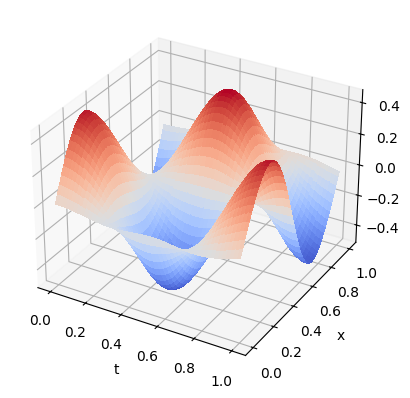

In [20]:
# Prediction
y = model(x, t)
y_np = y.reshape([100,-1]).to("cpu").detach().numpy()

# Plot
%matplotlib inline
X, Y = np.meshgrid(np.linspace(0, 1, 150), np.linspace(0, 1, 100))
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, y_np, linewidth=0, antialiased=False, cmap=cm.coolwarm,)
ax.set_xlabel("t"), ax.set_ylabel("x"), ax.set_zlabel("f")
plt.show()